In [1]:
import sys
sys.path.append('..')
from malign_logits.embedding import *

In [88]:
df = pd.read_parquet('../data/corpus_metrics.parquet')
df.columns

Index(['family', 'label', 'model', 'prompt', 'psg', 'n_sentences',
       'mean_drift', 'max_drift', 'std_drift', 'total_drift', 'path_length',
       'directedness', 'mean_surprisal', 'max_surprisal', 'std_surprisal',
       'n_tokens', 'token_mean_drift', 'token_max_drift', 'token_diameter',
       'token_path_length', 'token_directedness', 'metonymy_idx',
       'token_metonymy_idx', 'surprisal_pythia_1b_deduped', 'drift_bge_m3',
       'directedness_bge_m3'],
      dtype='str')

In [117]:
drift_cols = ['drift_bge_m3']
surpr_cols = ['surprisal_pythia_1b_deduped']
df['DRIFT'] = df[drift_cols].median(axis=1)
df['SURPRISAL'] = df[surpr_cols].median(axis=1)
df['DRIFT'] = (df['DRIFT'] - df['DRIFT'].mean()) / df['DRIFT'].std()
df['SURPRISAL'] = (df['SURPRISAL'] - df['SURPRISAL'].mean()) / df['SURPRISAL'].std()
df['is_ai'] = df.model.isin({'ego','base','superego','instruct'})
df['is_aligned'] = df.model.isin({'ego','superego','instruct'})

def classify_quadrant(d,s):
    if d > 0 and s > 0:
        return 'UR (Breakdown)'
    elif d < 0 and s > 0:
        return 'UL (Metonymic)'
    elif d < 0 and s < 0:
        return 'BL (Unmarked)'
    else:
        return 'BR (Metaphoric)'

def classify_genre(model,family):
    if family in {'qwen-tiny','olmo-tiny','smol','pythia'}:
        return None
    elif model in {'ego','superego','instruct'}:
        return 'AI (Aligned)'
    elif model == 'base':
        return 'AI (Base)'
    elif model == 'arxiv':
        return 'Abstracts'
    else:
        return model.title()
    

df['genre'] = [classify_genre(m,f) for m,f in zip(df.model,df.family)]
df['quadrant'] = [classify_quadrant(d,s) for d,s in zip(df.SURPRISAL,df.DRIFT)]

print(len(df))
# len(df[(df.DRIFT.abs()<5) & (df.SURPRISAL.abs()<5)])
df = df[(df.DRIFT.abs()<3) & (df.SURPRISAL.abs()<3)]
len(df)

76081


75188

In [118]:
df_smpl_ai = df[df.is_ai].groupby(['model','family']).sample(1000)

ValueError: Cannot take a larger sample than population when 'replace=False'

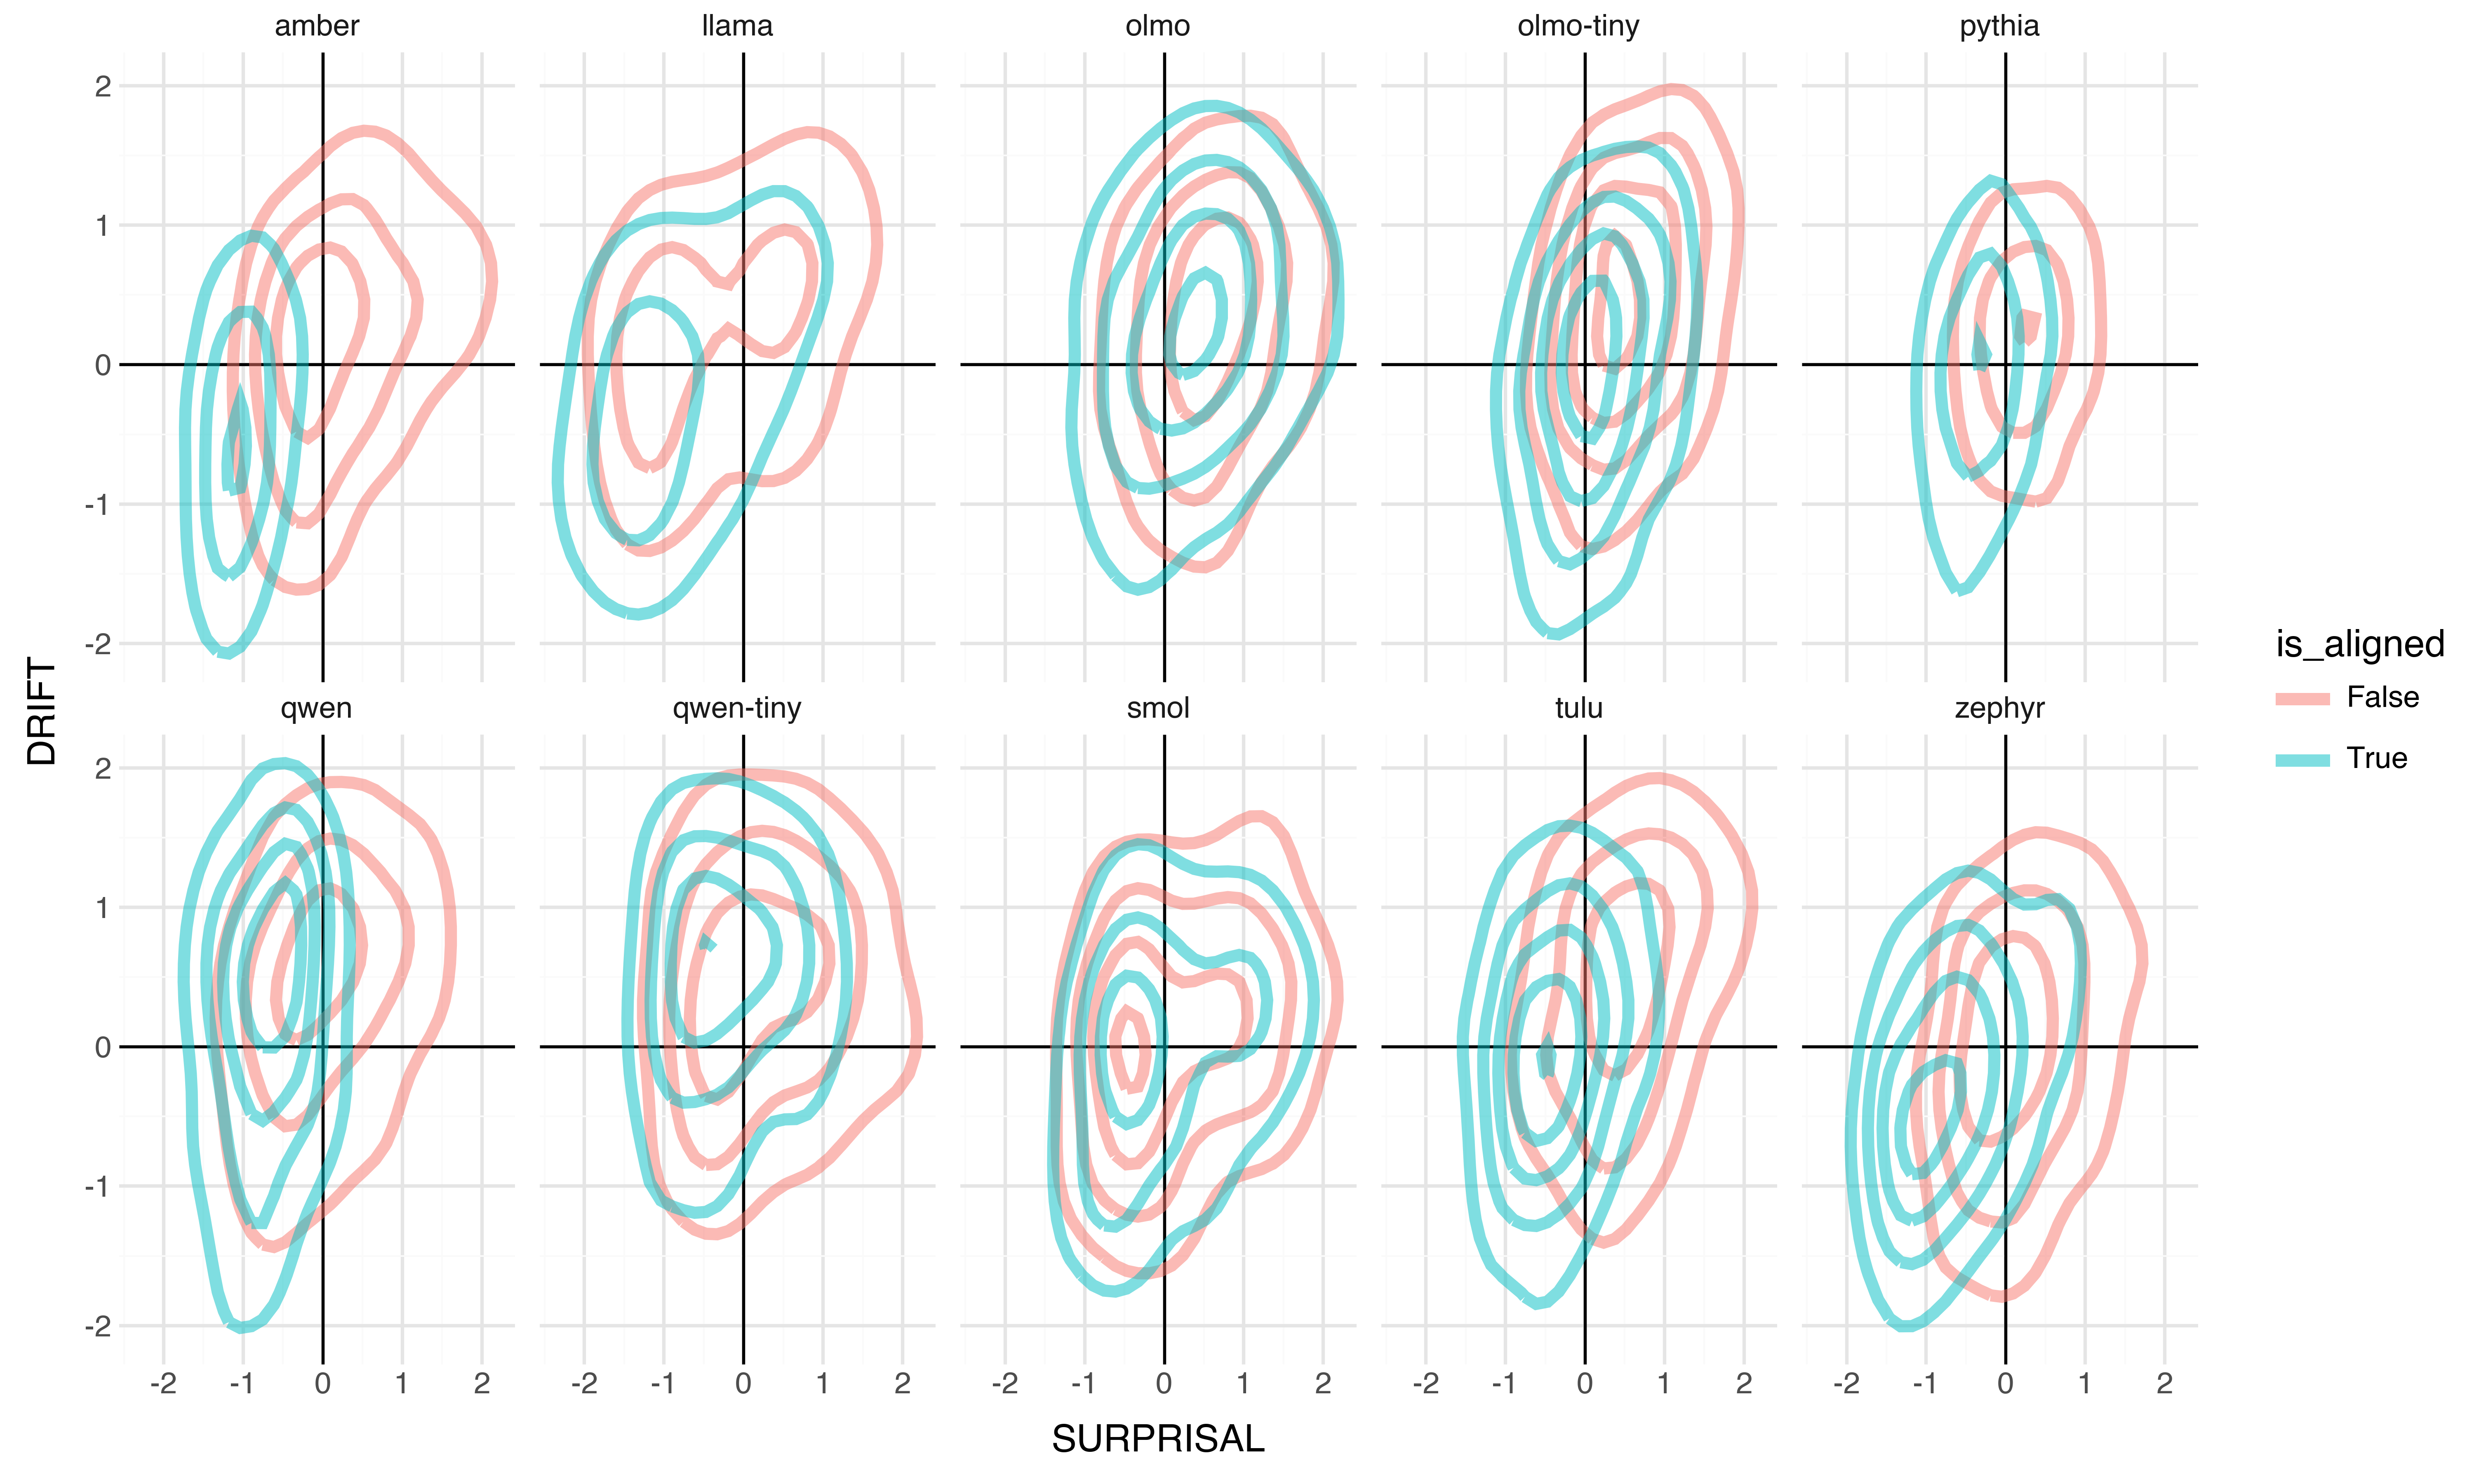

In [119]:
import plotnine as p9
p9.options.figure_size = (10, 6)
p9.options.dpi = 300
fig = (
    p9.ggplot(
        df_smpl_ai,
        p9.aes(x='SURPRISAL', y='DRIFT', color='is_aligned', fill='is_aligned')
    )
    # + p9.geom_point(size=.1,alpha=.1)
    + p9.geom_vline(xintercept=0, color='black', size=.5)
    + p9.geom_hline(yintercept=0, color='black', size=.5)
    + p9.geom_density_2d(size=2, alpha=.5)
    + p9.theme_minimal()
    + p9.facet_wrap('family',ncol=5)
    # + p9.scale_x_continuous(limits=(-5,5))
    # + p9.scale_y_continuous(limits=(-5,5))
    # + p9.facet_grid('is_aligned~family')
)
# fig.save('/Users/rj416/Dropbox/Prof/Confs/Accelerationism/figures/quadrants.png')
fig


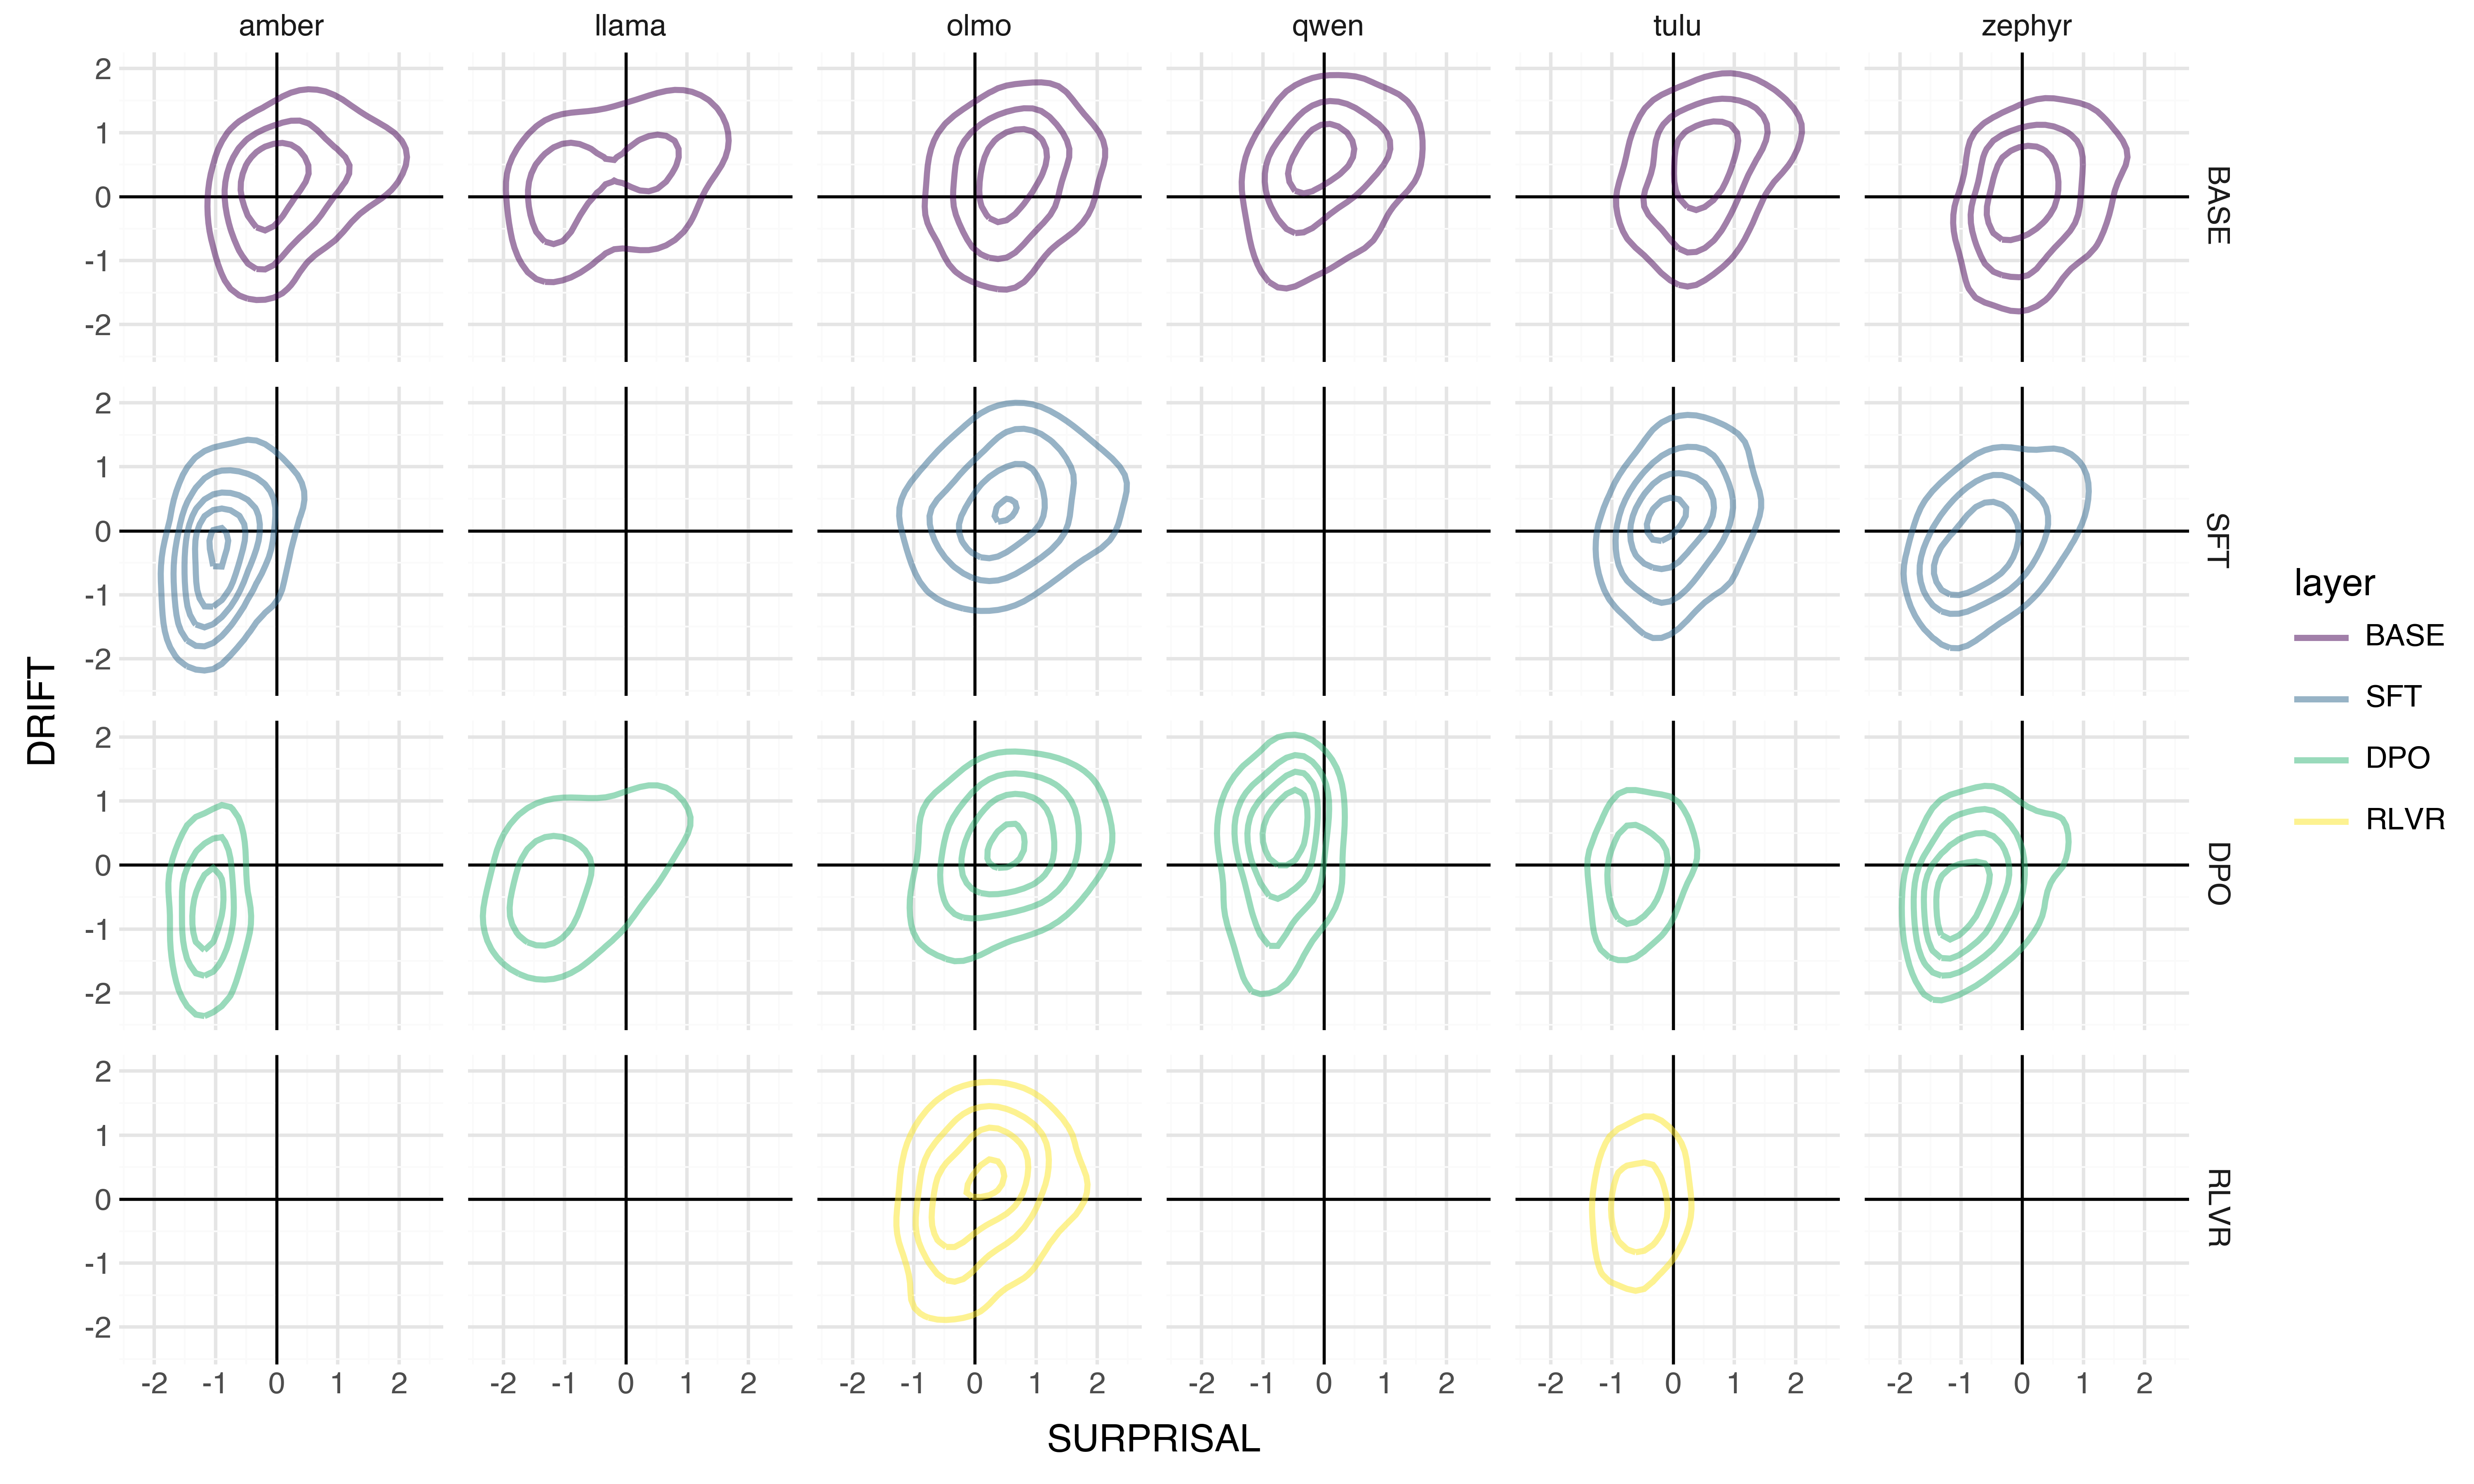

In [149]:
figdf=df_smpl_ai[~df_smpl_ai.family.isin({'qwen-tiny','olmo-tiny','smol','pythia'})]
figdf['layer'] = figdf['model'].replace({'ego':'SFT', 'superego':'DPO', 'instruct':'RLVR', 'base':'BASE'})
figdf['layer'] = pd.Categorical(figdf['layer'], categories=['BASE','SFT','DPO','RLVR'], ordered=True)

import plotnine as p9
p9.options.figure_size = (10, 6)
p9.options.dpi = 300
fig = (
    p9.ggplot(
        figdf,
        p9.aes(x='SURPRISAL', y='DRIFT', color='layer')
    )
    # + p9.geom_point(size=.1,alpha=.1)
    + p9.geom_vline(xintercept=0, color='black', size=.5)
    + p9.geom_hline(yintercept=0, color='black', size=.5)
    + p9.geom_density_2d(size=1, alpha=.5)
    + p9.theme_minimal()
    # + p9.facet_wrap('family',ncol=3)
    # + p9.scale_x_continuous(limits=(-5,5))
    # + p9.scale_y_continuous(limits=(-5,5))
    + p9.facet_grid('layer~family')
)
fig.save('/Users/rj416/Dropbox/Prof/Confs/Accelerationism/figures/quadrants-layers.png')
fig


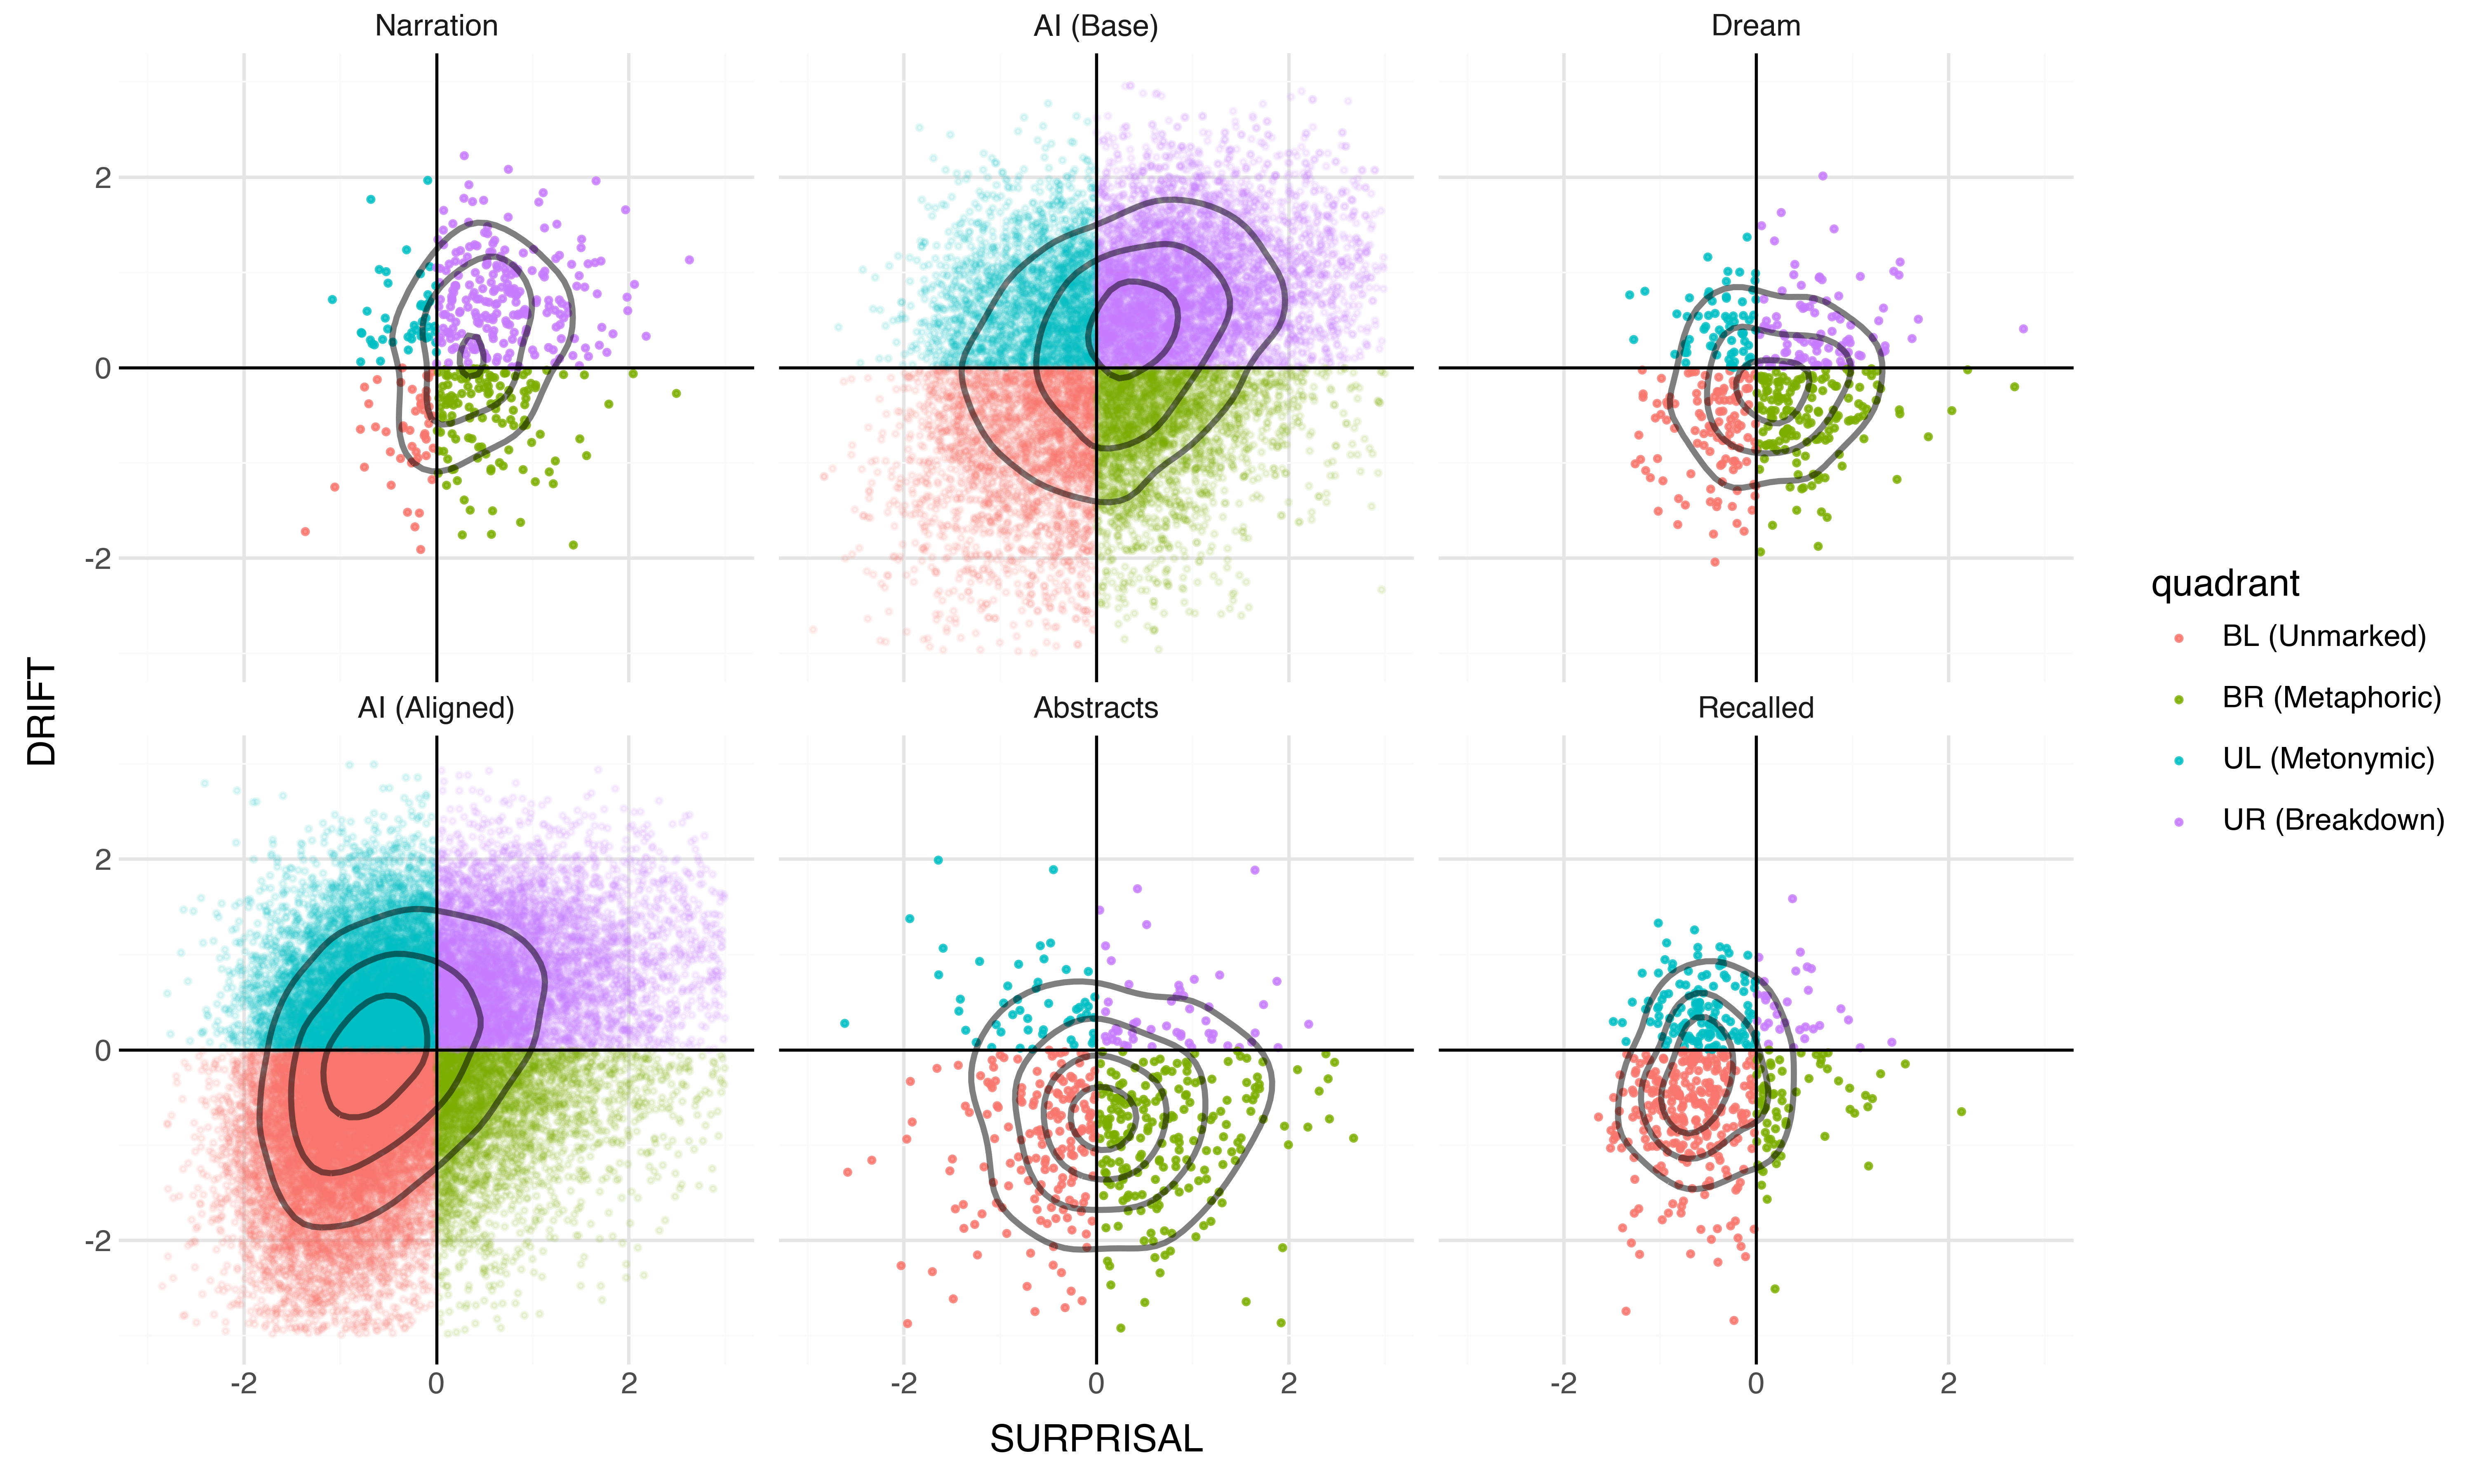

In [140]:
# figdf=df.groupby('genre').sample(400)
figdf = df[~df.genre.isna()].copy()
figdf['DRIFT_SURPRISAL'] = figdf['DRIFT'] + figdf['SURPRISAL']
figdf['genre'] = pd.Categorical(
    figdf['genre'],
    categories = figdf.groupby('genre').DRIFT_SURPRISAL.median().sort_values(ascending=False).index,
    ordered=True
)

import plotnine as p9
p9.options.figure_size = (10, 6)
p9.options.dpi = 300
fig = (
    p9.ggplot(
        figdf,
        p9.aes(x='SURPRISAL', y='DRIFT')
    )
    + p9.geom_point(p9.aes(color='quadrant'), size=.5,alpha=.1,data=figdf[figdf.is_ai])
    + p9.geom_point(p9.aes(color='quadrant'), size=.5,alpha=.8,data=figdf[~figdf.is_ai])
    + p9.geom_vline(xintercept=0, color='black', size=.5)
    + p9.geom_hline(yintercept=0, color='black', size=.5)
    + p9.geom_density_2d(size=1, alpha=.5)
    + p9.theme_minimal()
    + p9.facet_wrap('genre',ncol=3)
    + p9.scale_x_continuous(limits=(-3,3))
    + p9.scale_y_continuous(limits=(-3,3))
    # + p9.facet_grid('is_aligned~family')
)
fig.save('/Users/rj416/Dropbox/Prof/Confs/Accelerationism/figures/quadrants-genres.png')
fig
